In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [2]:
snapnum = 99

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [44]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

9
<class 'dict'>


In [6]:
h = 0.6774

In [7]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [68]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [10]:
m200c = np.log10((10**np.array(f["M200c"]))*h)
c200c = f["c200c"]
af = f["a_form"]

KeyboardInterrupt: 

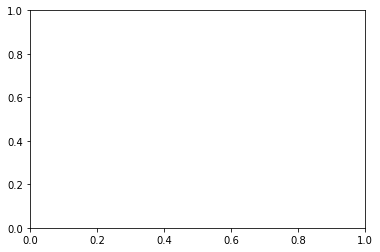

In [12]:
plt.hist(c200c)

In [34]:
c200_mask = (np.log10(c200c) < 1) & (np.array(c200c)>0) & (np.array(af) > 0)

In [35]:
stats.spearmanr(np.log10(c200c[c200_mask]), af[c200_mask])

SpearmanrResult(correlation=-0.4845556479339164, pvalue=0.0)

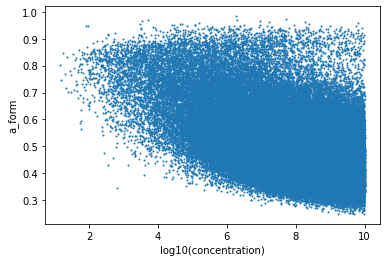

<Figure size 432x288 with 0 Axes>

In [36]:
plt.scatter(c200c[c200_mask], af[c200_mask], s=1)
plt.xlabel("log10(concentration)")
plt.ylabel("a_form")
plt.show()
plt.clf()

### Centrals

In [45]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [46]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [47]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


### Satellites

In [48]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [49]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [50]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [51]:
sum_sfrs = np.zeros(len(group_sfr))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0, 0.5, 'logMbh_cent')

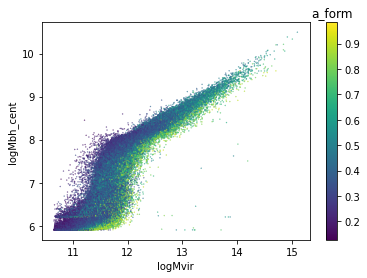

In [120]:
fig, ax = plt.subplots()
plt.scatter(mvir, Mbh_cent, c=af, s=0.1)
cbar = plt.colorbar()
cbar.ax.set_title("a_form")
plt.xlabel("logMvir")
plt.ylabel("logMbh_cent")

In [71]:
Mbh_sub = np.log10(subhalos["SubhaloBHMass"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [72]:
Mbh_cent =  np.zeros(len(mvir))
Mbh_cent[halos["GroupFirstSub"]>-1] = Mbh_sub[cent_mask_all]

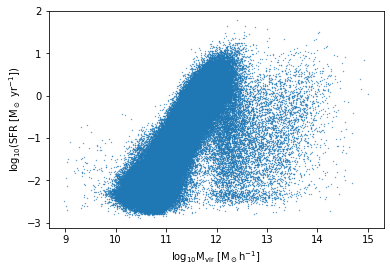

<Figure size 432x288 with 0 Axes>

In [84]:
plt.scatter(mvir, cent_sfrs, s=0.1)
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.show()
plt.clf()

In [113]:
mask1 = (mvir > 12.1) & (mvir < 12.2) #& (Mbh_cent > 7.5)

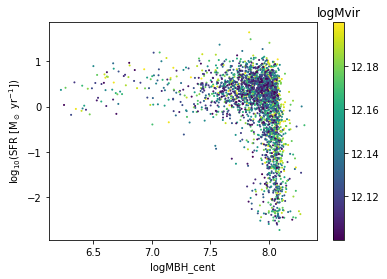

<Figure size 432x288 with 0 Axes>

In [114]:
fig,ax = plt.subplots()
plt.scatter(Mbh_cent[mask1], cent_sfrs[mask1], c=mvir[mask1], s=1)
cbar = plt.colorbar()
cbar.ax.set_title("logMvir")
plt.xlabel("logMBH_cent")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.show()
plt.clf()

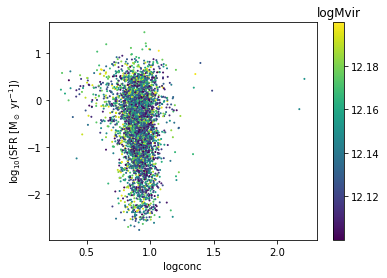

<Figure size 432x288 with 0 Axes>

In [115]:
fig,ax = plt.subplots()
plt.scatter(np.log10(c200c[mask1]), sum_sfrs[mask1], c=mvir[mask1], s=1)
cbar = plt.colorbar()
cbar.ax.set_title("logMvir")
plt.xlabel("logconc")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.show()
plt.clf()

In [104]:
stats.spearmanr(cent_sfrs[mask1 & (np.array(c200c) > 0)],np.log10(c200c[mask1&(np.array(c200c) > 0)]))

SpearmanrResult(correlation=-0.19428790384825362, pvalue=7.632757442707596e-19)

In [61]:
halo_quantity = c200c

In [111]:
dlogM = 0.1
mbin_cents = np.arange(8,15,dlogM)
coef_list = []
#frac_list = []
for mcent in mbin_cents:
    mask = (mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) & (np.array(halo_quantity) > 0) & (Mbh_cent > 7.5)
    # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
    # frac_list.append(frac)
    coef = stats.spearmanr(cent_sfrs[mask],np.log10(halo_quantity[mask]))[0]
    coef_list.append(coef)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/scipy/stats/stats.py:4196: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


Text(0, 0.5, 'Spearman correlation coefficient(SFR$_{cent}$, conc)')

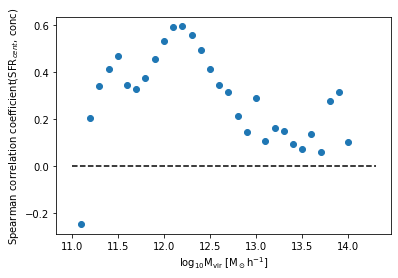

In [112]:
plt.scatter(mbin_cents[:-9], coef_list[:-9])
plt.plot([11,14.3], [0,0], linestyle="dashed", c="k")
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
#plt.ylabel("Spearman correlation coefficient(SFR$_{group}$, a$_{form}$)")
plt.ylabel("Spearman correlation coefficient(SFR$_{cent}$, conc)")